# Restaurant Sales Forecasting Project
## A Comprehensive Guide for Time Series Prediction

This notebook builds a sales forecasting system that predicts restaurant sales for three horizons: **1-day**, **7-day**, and **14-day** ahead

> **Note:** the original spec called for a 30-day horizon, but with only 60 days of raw data available, a 28-day lag + 30-day target would consume nearly the entire dataset before any row survives cleaning. The long-horizon target was shortened to **14 days** so the pipeline leaves a workable number of training/test rows. See Step 4.3 for details., following the full pipeline: data loading → cleaning → feature engineering → target creation → feature selection → train/test split → scaling → model training → evaluation.

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Step 1: Data Loading and Initial Inspection

**Objective:** Load the transaction data and understand its structure.

### 1.1 Load the Excel File

In [2]:
# Load the data — set sheet_name explicitly if the workbook has multiple sheets
df = pd.read_excel("Restaurant__transactions.xlsx", sheet_name=0)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")
df.head()

Loaded 22,896 rows and 5 columns.


,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,12:23:23,Test Bar,0.01,0.0230
2,2026-06-10,12:23:23,Test Juice,0.01,0.0115
3,2026-06-10,12:23:23,Test Coffee,0.01,0.0115
4,2026-06-10,12:23:23,Test Snack,0.01,0.0115


### 1.2 Date Conversion

Convert `Date` to a proper datetime dtype so we can sort, extract calendar features, and resample by day.

In [3]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print("Date column dtype:", df["Date"].dtype)

n_bad_dates = df["Date"].isna().sum()
print(f"Rows with unparseable dates: {n_bad_dates}")
if n_bad_dates:
    display(df[df["Date"].isna()])

Date column dtype: datetime64[us]
Rows with unparseable dates: 0


### 1.3 Data Exploration

In [4]:
print("Shape:", df.shape)
print("\nColumns and dtypes:")
print(df.dtypes)
print("\nInfo:")
df.info()

Shape: (22896, 5)

Columns and dtypes:
Date          datetime64[us]
Time                     str
Item                     str
UnitPrice            float64
TotalSales           float64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 22896 entries, 0 to 22895
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        22896 non-null  datetime64[us]
 1   Time        22896 non-null  str           
 2   Item        22896 non-null  str           
 3   UnitPrice   22896 non-null  float64       
 4   TotalSales  22896 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 1.3 MB


In [5]:
# Sort chronologically so head/tail reflect the actual date range
df = df.sort_values("Date").reset_index(drop=True)

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,19:32:09,Test Bar,0.01,0.0115
2,2026-06-10,19:21:15,Test Kitchen,0.01,0.0115
3,2026-06-10,19:16:05,Test Bar,0.01,0.0115
4,2026-06-10,19:11:42,Test Kitchen,0.01,0.0230



Last 5 rows:


,Date,Time,Item,UnitPrice,TotalSales
22891,2026-08-08,14:04:46,Yejebna Buna,55.34,140.0125
22892,2026-08-08,14:04:18,Soft Drink.,75.10,95.0015
22893,2026-08-08,14:04:18,Special Yebgi Tibs,1003.95,1270.0025
22894,2026-08-08,14:04:18,Special Kitfo,948.62,1200.0020
22895,2026-08-09,07:49:17,Yejebna Buna,55.34,70.0005


In [6]:
# Basic data-quality check
print("Missing values per column:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())

Missing values per column:
Date          0
Time          0
Item          0
UnitPrice     0
TotalSales    0
dtype: int64

Exact duplicate rows: 0


### 1.4 Date Range Analysis

In [7]:
min_date = df["Date"].min()
max_date = df["Date"].max()

print("Min date:", min_date.date())
print("Max date:", max_date.date())

total_days = (max_date - min_date).days + 1
print("Total days in range:", total_days)

unique_dates = df["Date"].nunique()
print("Unique dates in data:", unique_dates)

missing_days = total_days - unique_dates
print("Missing days (gaps):", missing_days)

if missing_days > 0:
    full_range = pd.date_range(min_date, max_date, freq="D")
    gaps = full_range.difference(df["Date"].unique())
    print(f"\nFirst few missing dates:\n{gaps[:10]}")

Min date: 2026-06-10
Max date: 2026-08-09
Total days in range: 61
Unique dates in data: 61
Missing days (gaps): 0


### 1.5 Pattern Identification

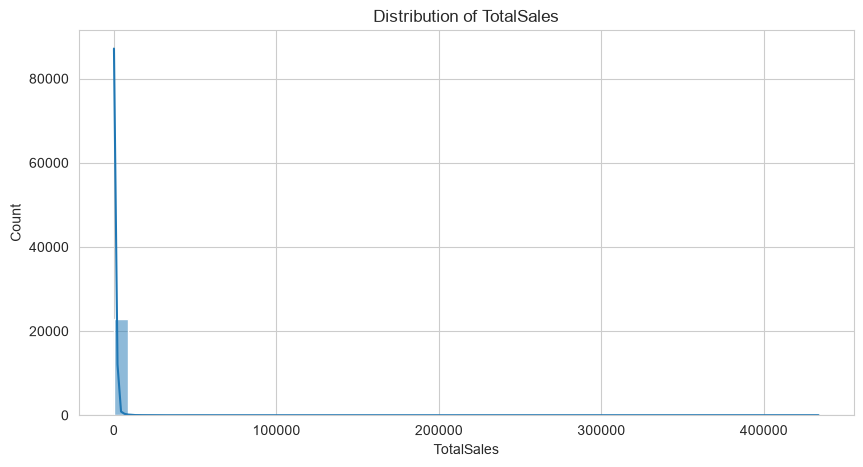

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df["TotalSales"], bins=50, kde=True)
plt.title("Distribution of TotalSales")
plt.xlabel("TotalSales")
plt.ylabel("Count")
plt.show()

In [9]:
print("Top 10 highest sales rows:")
display(df.nlargest(10, "TotalSales"))

print("\nBottom 10 lowest sales rows:")
display(df.nsmallest(10, "TotalSales"))

Top 10 highest sales rows:


,Date,Time,Item,UnitPrice,TotalSales
3723,2026-06-20,10:57:11,Refreshment & 1/2 Water,1261.88,433679.766
3725,2026-06-20,10:54:41,Refreshment & 1/2 Water,1261.88,374399.796
5264,2026-06-23,11:23:03,Refreshment & 1/2 Water,1496.46,255299.816
8106,2026-06-27,10:40:30,Refreshment & 1/2 Water,1439.84,231400.286
21110,2026-08-03,15:10:05,1st Class Buffee with Soft Drink,1855.73,220664.852
9645,2026-06-30,08:07:35,1st Class Buffee with Soft Drink,2002.02,197999.778
21109,2026-08-03,15:10:05,Refreshment & 1/2 Water,1302.37,154864.819
18757,2026-07-28,09:56:36,Special Siga Firefer,521.74,96360.156
21288,2026-08-04,11:31:15,Buffet 1st class w/soft drink for dinner,1897.23,95999.838
21289,2026-08-04,11:31:15,Buffet 1st Lunch with soft drink,1897.23,95999.838



Bottom 10 lowest sales rows:


,Date,Time,Item,UnitPrice,TotalSales
1,2026-06-10,19:32:09,Test Bar,0.01,0.0115
2,2026-06-10,19:21:15,Test Kitchen,0.01,0.0115
3,2026-06-10,19:16:05,Test Bar,0.01,0.0115
5,2026-06-10,19:11:42,Test Coffee,0.01,0.0115
8,2026-06-10,19:12:09,Test Bar,0.01,0.0115
11,2026-06-10,12:23:23,Test Snack,0.01,0.0115
12,2026-06-10,12:23:23,Test Coffee,0.01,0.0115
13,2026-06-10,12:23:23,Test Juice,0.01,0.0115
86,2026-06-11,18:30:28,Test Bar,0.01,0.0115
257,2026-06-11,07:33:12,Test Snack,0.01,0.0115


In [10]:
# Scan text columns for suspicious test/dummy entries
text_cols = df.select_dtypes(include="object").columns.tolist()
print("Text columns to inspect:", text_cols)

suspicious_terms = ["test", "sample", "dummy", "xxx", "n/a", "unknown"]
for col in text_cols:
    hits = df[df[col].astype(str).str.lower().str.contains("|".join(suspicious_terms), na=False)]
    if len(hits):
        print(f"\nPossible test/dummy entries in '{col}': {len(hits)} rows")
        display(hits.head())

Text columns to inspect: ['Time', 'Item']

Possible test/dummy entries in 'Item': 76 rows


C:\Users\hp\AppData\Local\Temp\ipykernel_5988\3245491064.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns.tolist()


,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,19:32:09,Test Bar,0.01,0.0115
2,2026-06-10,19:21:15,Test Kitchen,0.01,0.0115
3,2026-06-10,19:16:05,Test Bar,0.01,0.0115
4,2026-06-10,19:11:42,Test Kitchen,0.01,0.0230


### 1.6 Sales Statistics

Calculate basic statistics for the `TotalSales` column:
- Mean, median, minimum, and maximum values
- Standard deviation to understand sales variability
- Percentiles to understand the sales distribution

In [11]:
sales = df["TotalSales"]

stats = {
    "mean": sales.mean(),
    "median": sales.median(),
    "min": sales.min(),
    "max": sales.max(),
    "std": sales.std(),
}

print("Summary statistics:")
for k, v in stats.items():
    print(f"{k}: {v:.2f}")

print("\nPercentiles:")
print(sales.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Summary statistics:
mean: 663.22
median: 210.01
min: 0.01
max: 433679.77
std: 5255.31

Percentiles:
0.10      70.0005
0.25      95.0015
0.50     210.0130
0.75     649.9915
0.90    1270.0025
0.95    1679.9890
0.99    4800.0195
Name: TotalSales, dtype: float64


## Step 2: Data Cleaning and Preprocessing

**Objective:** Clean the dataset and remove items that could distort the analysis.

### 2.1 Filter Out Test Items
- Identify all transactions where the `Item` name contains the word "Test"
- Remove these rows from the dataset, as they represent system tests, not real sales
- Document the number of rows removed

In [12]:
test_mask = df["Item"].astype(str).str.contains("test", case=False, na=False)

n_test_rows = test_mask.sum()
print(f"Rows identified as test items: {n_test_rows}")

print("\nSample of test-item rows:")
display(df[test_mask].head())

df = df[~test_mask].reset_index(drop=True)

print(f"\nRows removed: {n_test_rows}")
print(f"Remaining rows: {len(df)}")

Rows identified as test items: 76

Sample of test-item rows:


,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,19:32:09,Test Bar,0.01,0.0115
2,2026-06-10,19:21:15,Test Kitchen,0.01,0.0115
3,2026-06-10,19:16:05,Test Bar,0.01,0.0115
4,2026-06-10,19:11:42,Test Kitchen,0.01,0.0230



Rows removed: 76
Remaining rows: 22820


### 2.2 Aggregate Daily Sales

- Group the cleaned data by `Date` to create a daily sales time series
- Sum `TotalSales` per date
- Rename the aggregated columns appropriately (`Date`, `TotalSales`)

**Safety check:** this cell always aggregates from `df` (never from a previous `daily`), and asserts the result has as many rows as `df` has unique dates. Re-running this cell is always safe and idempotent — it will never further collapse an already-aggregated result.

In [13]:
# Always aggregate fresh from df — never from a prior `daily` (re-running this
# cell is therefore always safe and won't progressively shrink the result)
expected_rows = df["Date"].nunique()

daily = df.groupby("Date", as_index=False)["TotalSales"].sum()
daily = daily.sort_values("Date").reset_index(drop=True)

print(f"Unique dates in df: {expected_rows}")
print(f"Daily time series shape: {daily.shape}")

assert len(daily) == expected_rows, (
    f"Aggregation produced {len(daily)} rows but df has {expected_rows} unique dates. "
    f"Something is wrong with this cell or with df before it — do not proceed."
)
print("Aggregation OK: row count matches unique date count.")

daily.head()

Unique dates in df: 60
Daily time series shape: (60, 2)
Aggregation OK: row count matches unique date count.


,Date,TotalSales
0,2026-06-11,210960.4390
1,2026-06-12,215435.2615
2,2026-06-13,268560.5235
3,2026-06-14,182505.2185
4,2026-06-15,301205.5505


### 2.3 Sort and Reset Index

In [14]:
daily = daily.sort_values("Date").reset_index(drop=True)

is_sorted = daily["Date"].is_monotonic_increasing
print("Data is sorted chronologically:", is_sorted)

daily.head()

Data is sorted chronologically: True


,Date,TotalSales
0,2026-06-11,210960.4390
1,2026-06-12,215435.2615
2,2026-06-13,268560.5235
3,2026-06-14,182505.2185
4,2026-06-15,301205.5505


### 2.4 Check for Missing Data

In [15]:
print("Missing values per column:")
print(daily.isna().sum())

full_range = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
missing_dates = full_range.difference(daily["Date"])

print(f"\nExpected days in range: {len(full_range)}")
print(f"Actual days present: {len(daily)}")
print(f"Missing days (gaps): {len(missing_dates)}")

if len(missing_dates) > 0:
    print("\nFirst 10 missing dates:")
    print(missing_dates[:10])

Missing values per column:
Date          0
TotalSales    0
dtype: int64

Expected days in range: 60
Actual days present: 60
Missing days (gaps): 0


### 2.5 Verify Data Integrity

In [16]:
all_dates_have_sales = daily["TotalSales"].notna().all()
print("All dates have a sales value:", all_dates_have_sales)

is_continuous = len(missing_dates) == 0
print("Time series is continuous:", is_continuous)

print("\n--- Data Integrity Summary ---")
if not is_continuous:
    print(f"Issue: {len(missing_dates)} missing day(s) in the sequence.")
    print("These represent days with zero recorded sales or unrecorded data.")
    print("Handling: addressed in feature engineering via lag/rolling operations that")
    print("tolerate gaps; alternatively, reindex and fill with 0 if closures are known.")
else:
    print("No issues found — daily series is complete and continuous.")

print(f"\nCurrent daily rows: {len(daily)}")

All dates have a sales value: True
Time series is continuous: True

--- Data Integrity Summary ---
No issues found — daily series is complete and continuous.

Current daily rows: 60


## Step 3: Feature Engineering

**Objective:** Create features that capture patterns in the time series data.

### 3.1 Time-Based Features
- Trend feature: sequential day index
- Calendar features: day of week, month, quarter, year
- Weekend indicator
- Month start indicator
- Cyclical encoding (sine/cosine) for day of week and month

In [17]:
daily["DayIndex"] = np.arange(len(daily))

daily["DayOfWeek"] = daily["Date"].dt.dayofweek   # 0=Monday, 6=Sunday
daily["Month"] = daily["Date"].dt.month
daily["Quarter"] = daily["Date"].dt.quarter
daily["Year"] = daily["Date"].dt.year

daily["IsWeekend"] = (daily["DayOfWeek"] >= 5).astype(int)
daily["IsMonthStart"] = daily["Date"].dt.is_month_start.astype(int)

daily["DayOfWeek_sin"] = np.sin(2 * np.pi * daily["DayOfWeek"] / 7)
daily["DayOfWeek_cos"] = np.cos(2 * np.pi * daily["DayOfWeek"] / 7)

daily["Month_sin"] = np.sin(2 * np.pi * daily["Month"] / 12)
daily["Month_cos"] = np.cos(2 * np.pi * daily["Month"] / 12)

daily.head()

,Date,TotalSales,DayIndex,DayOfWeek,Month,Quarter,Year,IsWeekend,IsMonthStart,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos
0,2026-06-11,210960.4390,0,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0
1,2026-06-12,215435.2615,1,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0
2,2026-06-13,268560.5235,2,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0
3,2026-06-14,182505.2185,3,6,6,2,2026,1,0,-0.781831,0.623490,1.224647e-16,-1.0
4,2026-06-15,301205.5505,4,0,6,2,2026,0,0,0.000000,1.000000,1.224647e-16,-1.0


### 3.2 Lag Features
- Short-term: 1, 2, 3, 5, 7 days
- Medium-term: 10, 14 days

**Adjusted for a 60-day dataset:** the original spec's 21- and 28-day lags were dropped, since combined with a 30-day-ahead target they would have consumed almost the entire dataset. Longest lag kept here is 14 days.

In [18]:
lag_periods = [1, 2, 3, 5, 7, 10, 14]

for lag in lag_periods:
    daily[f"Lag_{lag}"] = daily["TotalSales"].shift(lag)

n_nan_rows = daily[f"Lag_{max(lag_periods)}"].isna().sum()
print(f"Rows with NaN due to lagging (from the {max(lag_periods)}-day lag): {n_nan_rows}")

daily.head(10)

Rows with NaN due to lagging (from the 14-day lag): 14


,Date,TotalSales,DayIndex,DayOfWeek,Month,Quarter,Year,IsWeekend,IsMonthStart,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos,Lag_1,Lag_2,Lag_3,Lag_5,Lag_7,Lag_10,Lag_14
0,2026-06-11,2.109604e+05,0,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-12,2.154353e+05,1,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-13,2.685605e+05,2,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN
3,2026-06-14,1.825052e+05,3,6,6,2,2026,1,0,-0.781831,0.623490,1.224647e-16,-1.0,268560.5235,215435.2615,210960.4390,NaN,NaN,NaN,NaN
4,2026-06-15,3.012056e+05,4,0,6,2,2026,0,0,0.000000,1.000000,1.224647e-16,-1.0,182505.2185,268560.5235,215435.2615,NaN,NaN,NaN,NaN
5,2026-06-16,1.732202e+05,5,1,6,2,2026,0,0,0.781831,0.623490,1.224647e-16,-1.0,301205.5505,182505.2185,268560.5235,210960.4390,NaN,NaN,NaN
6,2026-06-17,1.625851e+05,6,2,6,2,2026,0,0,0.974928,-0.222521,1.224647e-16,-1.0,173220.2105,301205.5505,182505.2185,215435.2615,NaN,NaN,NaN
7,2026-06-18,2.242740e+05,7,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,162585.1370,173220.2105,301205.5505,268560.5235,210960.4390,NaN,NaN
8,2026-06-19,2.174852e+05,8,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,224273.9660,162585.1370,173220.2105,182505.2185,215435.2615,NaN,NaN
9,2026-06-20,1.153350e+06,9,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,217485.2055,224273.9660,162585.1370,301205.5505,268560.5235,NaN,NaN


### 3.3 Rolling Statistics
- Rolling means: 3, 7, 14-day windows
- Rolling std: 3, 7, 14-day windows

**Adjusted for a 60-day dataset:** the 30-day rolling window was dropped for the same reason as the 28-day lag above.
- Rolling min/max: 3 and 7-day windows

In [19]:
rolling_windows = [3, 7, 14]

for w in rolling_windows:
    daily[f"RollingMean_{w}"] = daily["TotalSales"].rolling(window=w).mean()

for w in rolling_windows:
    daily[f"RollingStd_{w}"] = daily["TotalSales"].rolling(window=w).std()

for w in [3, 7]:
    daily[f"RollingMin_{w}"] = daily["TotalSales"].rolling(window=w).min()
    daily[f"RollingMax_{w}"] = daily["TotalSales"].rolling(window=w).max()

daily.head(10)

,Date,TotalSales,DayIndex,DayOfWeek,Month,Quarter,Year,IsWeekend,IsMonthStart,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos,Lag_1,Lag_2,Lag_3,Lag_5,Lag_7,Lag_10,Lag_14,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_3,RollingStd_7,RollingStd_14,RollingMin_3,RollingMax_3,RollingMin_7,RollingMax_7
0,2026-06-11,2.109604e+05,0,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-12,2.154353e+05,1,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-13,2.685605e+05,2,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN,231652.074667,NaN,NaN,32041.866449,NaN,NaN,210960.4390,2.685605e+05,NaN,NaN
3,2026-06-14,1.825052e+05,3,6,6,2,2026,1,0,-0.781831,0.623490,1.224647e-16,-1.0,268560.5235,215435.2615,210960.4390,NaN,NaN,NaN,NaN,222167.001167,NaN,NaN,43420.802835,NaN,NaN,182505.2185,2.685605e+05,NaN,NaN
4,2026-06-15,3.012056e+05,4,0,6,2,2026,0,0,0.000000,1.000000,1.224647e-16,-1.0,182505.2185,268560.5235,215435.2615,NaN,NaN,NaN,NaN,250757.097500,NaN,NaN,61320.173575,NaN,NaN,182505.2185,3.012056e+05,NaN,NaN
5,2026-06-16,1.732202e+05,5,1,6,2,2026,0,0,0.781831,0.623490,1.224647e-16,-1.0,301205.5505,182505.2185,268560.5235,210960.4390,NaN,NaN,NaN,218976.993167,NaN,NaN,71363.187809,NaN,NaN,173220.2105,3.012056e+05,NaN,NaN
6,2026-06-17,1.625851e+05,6,2,6,2,2026,0,0,0.974928,-0.222521,1.224647e-16,-1.0,173220.2105,301205.5505,182505.2185,215435.2615,NaN,NaN,NaN,212336.966000,216353.191500,NaN,77145.934309,51401.354924,NaN,162585.1370,3.012056e+05,162585.137,3.012056e+05
7,2026-06-18,2.242740e+05,7,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,162585.1370,173220.2105,301205.5505,268560.5235,210960.4390,NaN,NaN,186693.104500,218255.123929,NaN,32977.523564,51414.866833,NaN,162585.1370,2.242740e+05,162585.137,3.012056e+05
8,2026-06-19,2.174852e+05,8,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,224273.9660,162585.1370,173220.2105,182505.2185,215435.2615,NaN,NaN,201448.102833,218547.973071,NaN,33827.051339,51401.964967,NaN,162585.1370,2.242740e+05,162585.137,3.012056e+05
9,2026-06-20,1.153350e+06,9,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,217485.2055,224273.9660,162585.1370,301205.5505,268560.5235,NaN,NaN,531703.078833,344946.479000,NaN,538372.782907,359483.562856,NaN,217485.2055,1.153350e+06,162585.137,1.153350e+06


### 3.4 Derived Features
- Daily change, weekly change
- Day-of-week average, sales-to-DOW ratio
- Sales-to-rolling-average ratios
- Std ratio (3-day vs 7-day)

In [20]:
daily["DailyChange"] = daily["TotalSales"].pct_change()
daily["WeeklyChange"] = daily["TotalSales"].pct_change(periods=7)

dow_avg = daily.groupby("DayOfWeek")["TotalSales"].transform("mean")
daily["DOW_Average"] = dow_avg
daily["Sales_to_DOW_Ratio"] = daily["TotalSales"] / daily["DOW_Average"]

daily["Sales_to_RollingMean_7_Ratio"] = daily["TotalSales"] / daily["RollingMean_7"]
daily["Sales_to_RollingMean_14_Ratio"] = daily["TotalSales"] / daily["RollingMean_14"]

daily["Std_Ratio_3_to_7"] = daily["RollingStd_3"] / daily["RollingStd_7"]

daily.head(10)

,Date,TotalSales,DayIndex,DayOfWeek,Month,Quarter,Year,IsWeekend,IsMonthStart,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos,Lag_1,Lag_2,Lag_3,Lag_5,Lag_7,Lag_10,Lag_14,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_3,RollingStd_7,RollingStd_14,RollingMin_3,RollingMax_3,RollingMin_7,RollingMax_7,DailyChange,WeeklyChange,DOW_Average,Sales_to_DOW_Ratio,Sales_to_RollingMean_7_Ratio,Sales_to_RollingMean_14_Ratio,Std_Ratio_3_to_7
0,2026-06-11,2.109604e+05,0,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,229968.561556,0.917345,NaN,NaN,NaN
1,2026-06-12,2.154353e+05,1,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021212,NaN,210136.120278,1.025218,NaN,NaN,NaN
2,2026-06-13,2.685605e+05,2,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN,231652.074667,NaN,NaN,32041.866449,NaN,NaN,210960.4390,2.685605e+05,NaN,NaN,0.246595,NaN,377948.150389,0.710575,NaN,NaN,NaN
3,2026-06-14,1.825052e+05,3,6,6,2,2026,1,0,-0.781831,0.623490,1.224647e-16,-1.0,268560.5235,215435.2615,210960.4390,NaN,NaN,NaN,NaN,222167.001167,NaN,NaN,43420.802835,NaN,NaN,182505.2185,2.685605e+05,NaN,NaN,-0.320432,NaN,181242.048278,1.006970,NaN,NaN,NaN
4,2026-06-15,3.012056e+05,4,0,6,2,2026,0,0,0.000000,1.000000,1.224647e-16,-1.0,182505.2185,268560.5235,215435.2615,NaN,NaN,NaN,NaN,250757.097500,NaN,NaN,61320.173575,NaN,NaN,182505.2185,3.012056e+05,NaN,NaN,0.650394,NaN,231017.364750,1.303822,NaN,NaN,NaN
5,2026-06-16,1.732202e+05,5,1,6,2,2026,0,0,0.781831,0.623490,1.224647e-16,-1.0,301205.5505,182505.2185,268560.5235,210960.4390,NaN,NaN,NaN,218976.993167,NaN,NaN,71363.187809,NaN,NaN,173220.2105,3.012056e+05,NaN,NaN,-0.424910,NaN,357109.485625,0.485062,NaN,NaN,NaN
6,2026-06-17,1.625851e+05,6,2,6,2,2026,0,0,0.974928,-0.222521,1.224647e-16,-1.0,173220.2105,301205.5505,182505.2185,215435.2615,NaN,NaN,NaN,212336.966000,216353.191500,NaN,77145.934309,51401.354924,NaN,162585.1370,3.012056e+05,162585.137,3.012056e+05,-0.061396,NaN,185791.666938,0.875094,0.751480,NaN,1.500854
7,2026-06-18,2.242740e+05,7,3,6,2,2026,0,0,0.433884,-0.900969,1.224647e-16,-1.0,162585.1370,173220.2105,301205.5505,268560.5235,210960.4390,NaN,NaN,186693.104500,218255.123929,NaN,32977.523564,51414.866833,NaN,162585.1370,2.242740e+05,162585.137,3.012056e+05,0.379425,0.063109,229968.561556,0.975238,1.027577,NaN,0.641401
8,2026-06-19,2.174852e+05,8,4,6,2,2026,0,0,-0.433884,-0.900969,1.224647e-16,-1.0,224273.9660,162585.1370,173220.2105,182505.2185,215435.2615,NaN,NaN,201448.102833,218547.973071,NaN,33827.051339,51401.964967,NaN,162585.1370,2.242740e+05,162585.137,3.012056e+05,-0.030270,0.009515,210136.120278,1.034973,0.995137,NaN,0.658089
9,2026-06-20,1.153350e+06,9,5,6,2,2026,1,0,-0.974928,-0.222521,1.224647e-16,-1.0,217485.2055,224273.9660,162585.1370,301205.5505,268560.5235,NaN,NaN,531703.078833,344946.479000,NaN,538372.782907,359483.562856,NaN,217485.2055,1.153350e+06,162585.137,1.153350e+06,4.303120,3.294563,377948.150389,3.051609,3.343562,NaN,1.497628


### 3.5 Data Cleaning
- Drop rows where any feature has NaN values (created by lags/rolling)
- Verify no missing values remain
- Document final dataset size and date range

In [21]:
rows_before = len(daily)

daily = daily.dropna().reset_index(drop=True)

rows_after = len(daily)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows dropped: {rows_before - rows_after}")
print(f"Rows after cleaning: {rows_after}")

print("\nRemaining missing values:", daily.isna().sum().sum())

if rows_after > 0:
    print(f"\nFinal dataset shape: {daily.shape}")
    print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
else:
    print("\nWARNING: 0 rows remain after dropna(). Your dataset likely doesn't span")
    print("enough days to support even the reduced 14-day lag / rolling windows.")
    print("shortening the longest lag/rolling windows, or check the row counts at")
    print("each earlier step (raw load -> test-item filter -> daily aggregation).")

Rows before cleaning: 60
Rows dropped: 14
Rows after cleaning: 46

Remaining missing values: 0

Final dataset shape: (46, 37)
Date range: 2026-06-25 to 2026-08-09


## Step 4: Target Creation

**Objective:** Prepare target variables for three different forecasting horizons.

### 4.1 1-Day Target
- Total sales for the next day, `TotalSales` shifted backward by 1 day
- Column name: `target_1d`

In [22]:
daily["target_1d"] = daily["TotalSales"].shift(-1)
daily[["Date", "TotalSales", "target_1d"]].head(10)

,Date,TotalSales,target_1d
0,2026-06-25,471845.9545,379930.7210
1,2026-06-26,379930.7210,844791.0465
2,2026-06-27,844791.0465,300995.3765
3,2026-06-28,300995.3765,192639.6740
4,2026-06-29,192639.6740,489180.5715
5,2026-06-30,489180.5715,212070.4190
6,2026-07-01,212070.4190,320354.8560
7,2026-07-02,320354.8560,241520.3435
8,2026-07-03,241520.3435,224205.1845
9,2026-07-04,224205.1845,219705.1310


### 4.2 7-Day Target
- Total sales for the next 7 days (cumulative): rolling 7-day sum, shifted backward by 7 days
- Column name: `target_7d`

In [23]:
daily["target_7d"] = daily["TotalSales"].rolling(window=7).sum().shift(-7)
daily[["Date", "TotalSales", "target_7d"]].head(10)

,Date,TotalSales,target_7d
0,2026-06-25,471845.9545,2.739963e+06
1,2026-06-26,379930.7210,2.601552e+06
2,2026-06-27,844791.0465,1.980966e+06
3,2026-06-28,300995.3765,1.899676e+06
4,2026-06-29,192639.6740,1.805162e+06
5,2026-06-30,489180.5715,1.421486e+06
6,2026-07-01,212070.4190,1.339885e+06
7,2026-07-02,320354.8560,1.144958e+06
8,2026-07-03,241520.3435,1.058944e+06
9,2026-07-04,224205.1845,1.004225e+06


### 4.3 14-Day Target (adjusted from the original 30-day spec)
- **Why 14 days, not 30:** with only 60 days of raw data, a 28-day lag + 30-day target would require 58+ days of buffer, leaving almost no usable rows. A 14-day lag + 14-day target requires 28 days of buffer instead, leaving ~32 usable rows — enough for a meaningful train/test split.
- Total sales for the next 14 days (cumulative): rolling 14-day sum, shifted backward by 14 days
- Column name: `target_14d`

In [24]:
daily["target_14d"] = daily["TotalSales"].rolling(window=14).sum().shift(-14)
daily[["Date", "TotalSales", "target_14d"]].head(10)

,Date,TotalSales,target_14d
0,2026-06-25,471845.9545,3.884921e+06
1,2026-06-26,379930.7210,3.660496e+06
2,2026-06-27,844791.0465,2.985192e+06
3,2026-06-28,300995.3765,2.817080e+06
4,2026-06-29,192639.6740,2.727039e+06
5,2026-06-30,489180.5715,2.380107e+06
6,2026-07-01,212070.4190,2.373584e+06
7,2026-07-02,320354.8560,2.246847e+06
8,2026-07-03,241520.3435,2.132092e+06
9,2026-07-04,224205.1845,2.033273e+06


### 4.4 Clean Up
- Drop rows where any target is NaN (end of dataset)
- Verify alignment between targets and features
- Confirm final dataset has no missing values

In [25]:
rows_before = len(daily)

target_cols = ["target_1d", "target_7d", "target_14d"]
daily = daily.dropna(subset=target_cols).reset_index(drop=True)

rows_after = len(daily)
print(f"Rows dropped (missing targets): {rows_before - rows_after}")
print(f"Final rows: {rows_after}")

if rows_after > 1:
    alignment_ok = (daily["target_1d"].iloc[:-1].values == daily["TotalSales"].shift(-1).dropna().values).all()
    print(f"target_1d alignment check passed: {alignment_ok}")

print(f"Remaining NaNs in full dataset: {daily.isna().sum().sum()}")

if rows_after > 0:
    print(f"\nFinal dataset shape: {daily.shape}")
    print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
else:
    print("\nWARNING: 0 rows remain. Cannot proceed to feature selection / modeling")
    print("until the dataset has enough date coverage for the longest lag (14 days)")
    print("plus the longest forward target (14 days) — roughly 28+ days minimum.")

Rows dropped (missing targets): 14
Final rows: 32
target_1d alignment check passed: True
Remaining NaNs in full dataset: 0

Final dataset shape: (32, 40)
Date range: 2026-06-25 to 2026-07-26


## Step 5: Feature Selection

**Objective:** Select the most relevant features for each forecasting horizon.

### 5.1 Feature Categories

In [26]:
feature_categories = {
    "time": ["DayIndex", "Quarter", "IsWeekend", "IsMonthStart",
             "DayOfWeek_sin", "DayOfWeek_cos", "Month_sin", "Month_cos"],
    "lag": ["Lag_1", "Lag_2", "Lag_3", "Lag_5", "Lag_7", "Lag_10", "Lag_14"],
    "rolling": ["RollingMean_3", "RollingMean_7", "RollingMean_14",
                "RollingStd_3", "RollingStd_7", "RollingStd_14"],
    "derived": ["DailyChange", "WeeklyChange", "DOW_Average", "Sales_to_DOW_Ratio",
                "Sales_to_RollingMean_7_Ratio", "Sales_to_RollingMean_14_Ratio", "Std_Ratio_3_to_7"],
}

for category, cols in feature_categories.items():
    missing = [c for c in cols if c not in daily.columns]
    print(f"{category}: {len(cols)} features" + (f"  (MISSING: {missing})" if missing else ""))

time: 8 features
lag: 7 features
rolling: 6 features
derived: 7 features


### 5.2 Feature Selection for 1-Day Horizon
Short-term lags/rolling stats + weekend/day-of-week — tomorrow's sales are most influenced by very recent days.

In [27]:
features_1d = [
    "Lag_1", "Lag_2", "Lag_3",
    "RollingMean_3", "RollingMean_7",
    "RollingStd_3",
    "IsWeekend", "DayOfWeek_sin", "DayOfWeek_cos",
]

print(f"1-day horizon features ({len(features_1d)}):")
print(features_1d)

1-day horizon features (9):
['Lag_1', 'Lag_2', 'Lag_3', 'RollingMean_3', 'RollingMean_7', 'RollingStd_3', 'IsWeekend', 'DayOfWeek_sin', 'DayOfWeek_cos']


### 5.3 Feature Selection for 7-Day Horizon
Weekly lags/rolling stats — weekly sales depend on the same week in previous weeks and medium-term trends.

In [28]:
features_7d = [
    "Lag_7", "Lag_14",
    "RollingMean_7", "RollingMean_14",
    "RollingStd_7",
    "DayOfWeek_sin", "DayOfWeek_cos", "IsWeekend",
    "Sales_to_RollingMean_7_Ratio", "WeeklyChange",
]

print(f"7-day horizon features ({len(features_7d)}):")
print(features_7d)

7-day horizon features (10):
['Lag_7', 'Lag_14', 'RollingMean_7', 'RollingMean_14', 'RollingStd_7', 'DayOfWeek_sin', 'DayOfWeek_cos', 'IsWeekend', 'Sales_to_RollingMean_7_Ratio', 'WeeklyChange']


### 5.4 Feature Selection for 14-Day Horizon (adjusted from 30-day)
Long-term lags/rolling stats + monthly seasonality — monthly sales depend on longer-term patterns and trends.

In [29]:
features_14d = [
    "Lag_10", "Lag_14",
    "RollingMean_14",
    "DayIndex", "Month_sin", "Month_cos", "IsMonthStart",
    "Sales_to_RollingMean_14_Ratio",
]

print(f"14-day horizon features ({len(features_14d)}):")
print(features_14d)

14-day horizon features (8):
['Lag_10', 'Lag_14', 'RollingMean_14', 'DayIndex', 'Month_sin', 'Month_cos', 'IsMonthStart', 'Sales_to_RollingMean_14_Ratio']


### 5.5 Create Feature Sets
`X_1d`, `X_7d`, `X_14d` and targets `y_1d`, `y_7d`, `y_14d` — with verification that all selected features exist.

In [30]:
feature_sets = {
    "1d": (features_1d, "target_1d"),
    "7d": (features_7d, "target_7d"),
    "14d": (features_14d, "target_14d"),
}

for horizon, (feats, target_col) in feature_sets.items():
    missing = [f for f in feats if f not in daily.columns]
    status = "OK" if not missing else f"MISSING: {missing}"
    print(f"{horizon}: {len(feats)} features, target='{target_col}' — {status}")

X_1d, y_1d = daily[features_1d], daily["target_1d"]
X_7d, y_7d = daily[features_7d], daily["target_7d"]
X_14d, y_14d = daily[features_14d], daily["target_14d"]

print("\nFinal shapes:")
print(f"  1-day:  X={X_1d.shape}, y={y_1d.shape}")
print(f"  7-day:  X={X_7d.shape}, y={y_7d.shape}")
print(f"  14-day: X={X_14d.shape}, y={y_14d.shape}")

1d: 9 features, target='target_1d' — OK
7d: 10 features, target='target_7d' — OK
14d: 8 features, target='target_14d' — OK

Final shapes:
  1-day:  X=(32, 9), y=(32,)
  7-day:  X=(32, 10), y=(32,)
  14-day: X=(32, 8), y=(32,)


## Step 6: Train-Test Split and Scaling

**Objective:** Split the data chronologically and scale the features.

### 6.1 Chronological Split
No shuffling (would cause data leakage). 80% train / 20% test, in chronological order.

In [31]:
def chronological_split(X, y, train_frac=0.8):
    if len(X) == 0:
        raise ValueError(
            "Cannot split an empty dataset (0 rows). "
            "Check Steps 2-4 — daily.dropna() likely removed all rows."
        )
    split_idx = int(len(X) * train_frac)
    if split_idx == 0 or split_idx == len(X):
        raise ValueError(
            f"Split produced an empty train or test set "
            f"(train={split_idx} rows, test={len(X) - split_idx} rows) "
            f"from only {len(X)} total rows. Dataset is too small for this split."
        )
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    return X_train, X_test, y_train, y_test

print("Rows in daily:", len(daily))
if len(daily) > 0:
    print("Date range:", daily['Date'].min(), "to", daily['Date'].max())

    split_idx = int(len(daily) * 0.8)
    print(f"\nPlanned split -> train: {split_idx} rows, test: {len(daily) - split_idx} rows")
    if len(daily) > 1:
        print(f"Train: {daily['Date'].iloc[0].date()} to {daily['Date'].iloc[split_idx - 1].date()}")
        print(f"Test:  {daily['Date'].iloc[split_idx].date()} to {daily['Date'].iloc[-1].date()}")
else:
    print("WARNING: daily is empty — resolve upstream row-count issues before continuing.")

Rows in daily: 32
Date range: 2026-06-25 00:00:00 to 2026-07-26 00:00:00

Planned split -> train: 25 rows, test: 7 rows
Train: 2026-06-25 to 2026-07-19
Test:  2026-07-20 to 2026-07-26


### 6.2 Split for Each Horizon

In [32]:
X_train_1d, X_test_1d, y_train_1d, y_test_1d = chronological_split(X_1d, y_1d)
X_train_7d, X_test_7d, y_train_7d, y_test_7d = chronological_split(X_7d, y_7d)
X_train_14d, X_test_14d, y_train_14d, y_test_14d = chronological_split(X_14d, y_14d)

for horizon, (X_tr, X_te) in {
    "1d": (X_train_1d, X_test_1d),
    "7d": (X_train_7d, X_test_7d),
    "14d": (X_train_14d, X_test_14d),
}.items():
    print(f"{horizon}: train={X_tr.shape}, test={X_te.shape}")

1d: train=(25, 9), test=(7, 9)
7d: train=(25, 10), test=(7, 10)
14d: train=(25, 8), test=(7, 8)


### 6.3 Feature Scaling
`StandardScaler`, fit only on training data, applied to both train and test — a separate scaler per horizon.

In [33]:
scaler_1d = StandardScaler()
scaler_7d = StandardScaler()
scaler_14d = StandardScaler()

X_train_1d_scaled = pd.DataFrame(scaler_1d.fit_transform(X_train_1d), columns=X_train_1d.columns, index=X_train_1d.index)
X_test_1d_scaled = pd.DataFrame(scaler_1d.transform(X_test_1d), columns=X_test_1d.columns, index=X_test_1d.index)

X_train_7d_scaled = pd.DataFrame(scaler_7d.fit_transform(X_train_7d), columns=X_train_7d.columns, index=X_train_7d.index)
X_test_7d_scaled = pd.DataFrame(scaler_7d.transform(X_test_7d), columns=X_test_7d.columns, index=X_test_7d.index)

X_train_14d_scaled = pd.DataFrame(scaler_14d.fit_transform(X_train_14d), columns=X_train_14d.columns, index=X_train_14d.index)
X_test_14d_scaled = pd.DataFrame(scaler_14d.transform(X_test_14d), columns=X_test_14d.columns, index=X_test_14d.index)

print("Train (1d) scaled — mean:\n", X_train_1d_scaled.mean().round(2).values)
print("Train (1d) scaled — std:\n", X_train_1d_scaled.std().round(2).values)

Train (1d) scaled — mean:
 [-0. -0. -0. -0.  0.  0. -0.  0.  0.]
Train (1d) scaled — std:
 [1.02 1.02 1.02 1.02 1.02 1.02 1.02 1.02 1.02]


## Step 7: Model Training

**Objective:** Train prediction models for each forecasting horizon.

### 7.1 Model Selection
- Baseline: Linear Regression (default params)
- Advanced: Random Forest Regressor (n_estimators, max_depth, min_samples_split set explicitly)
- Both trained for all three horizons

In [34]:
models = {}

horizon_train_data = {
    "1d": (X_train_1d_scaled, y_train_1d),
    "7d": (X_train_7d_scaled, y_train_7d),
    "14d": (X_train_14d_scaled, y_train_14d),
}

for horizon, (X_tr, y_tr) in horizon_train_data.items():
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        random_state=42,
    )
    rf.fit(X_tr, y_tr)

    models[horizon] = {"linear_regression": lr, "random_forest": rf}
    print(f"Trained models for {horizon} horizon: Linear Regression, Random Forest")

Trained models for 1d horizon: Linear Regression, Random Forest
Trained models for 7d horizon: Linear Regression, Random Forest
Trained models for 14d horizon: Linear Regression, Random Forest


### 7.2 Training Process (confirmation)

In [35]:
for horizon, m in models.items():
    print(f"{horizon} horizon:")
    print(f"  Linear Regression trained on X_train_{horizon}_scaled -> {m['linear_regression']}")
    print(f"  Random Forest trained on X_train_{horizon}_scaled     -> {m['random_forest']}")

1d horizon:
  Linear Regression trained on X_train_1d_scaled -> LinearRegression()
  Random Forest trained on X_train_1d_scaled     -> RandomForestRegressor(max_depth=8, min_samples_split=5, n_estimators=200,
                      random_state=42)
7d horizon:
  Linear Regression trained on X_train_7d_scaled -> LinearRegression()
  Random Forest trained on X_train_7d_scaled     -> RandomForestRegressor(max_depth=8, min_samples_split=5, n_estimators=200,
                      random_state=42)
14d horizon:
  Linear Regression trained on X_train_14d_scaled -> LinearRegression()
  Random Forest trained on X_train_14d_scaled     -> RandomForestRegressor(max_depth=8, min_samples_split=5, n_estimators=200,
                      random_state=42)


### 7.3 Hyperparameter Tuning
Grid Search with `TimeSeriesSplit` (not standard k-fold, to avoid leaking future data into training) over Random Forest parameters. Linear Regression uses default parameters.

In [36]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

tscv = TimeSeriesSplit(n_splits=5)
tuned_models = {}

for horizon, (X_tr, y_tr) in horizon_train_data.items():
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    grid_search.fit(X_tr, y_tr)

    tuned_models[horizon] = grid_search.best_estimator_
    print(f"{horizon} horizon — best params: {grid_search.best_params_}")

    models[horizon]["random_forest"] = grid_search.best_estimator_

1d horizon — best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
7d horizon — best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
14d horizon — best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


### 7.4 Feature Importance Analysis
Extract and rank Random Forest feature importances per horizon; identify features consistently important across all horizons.

In [37]:
importance_by_horizon = {}

for horizon, feats in [("1d", features_1d), ("7d", features_7d), ("14d", features_14d)]:
    rf = models[horizon]["random_forest"]
    importances = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
    importance_by_horizon[horizon] = importances

    print(f"\nTop features — {horizon} horizon:")
    print(importances.head(10))

top5_sets = {h: set(imp.head(5).index) for h, imp in importance_by_horizon.items()}
consistently_important = top5_sets["1d"] & top5_sets["7d"] & top5_sets["14d"]
print(f"\nFeatures in top 5 across ALL horizons: {consistently_important}")


Top features — 1d horizon:
RollingMean_7    0.329826
RollingMean_3    0.226206
Lag_2            0.142626
RollingStd_3     0.110926
Lag_1            0.109007
Lag_3            0.060604
DayOfWeek_sin    0.015372
DayOfWeek_cos    0.004095
IsWeekend        0.001338
dtype: float64

Top features — 7d horizon:
RollingMean_7                   0.615780
RollingStd_7                    0.233568
WeeklyChange                    0.048151
Lag_14                          0.027738
Sales_to_RollingMean_7_Ratio    0.017881
DayOfWeek_cos                   0.016930
RollingMean_14                  0.014801
Lag_7                           0.013911
DayOfWeek_sin                   0.009247
IsWeekend                       0.001994
dtype: float64

Top features — 14d horizon:
Sales_to_RollingMean_14_Ratio    0.486843
DayIndex                         0.205613
Lag_10                           0.196703
Lag_14                           0.040183
RollingMean_14                   0.039011
Month_sin                      

## Step 8: Evaluation and Visualization

**Objective:** Evaluate model performance and visualize results.

### 8.1 Generate Predictions

In [38]:
predictions = {}

horizon_test_data = {
    "1d": X_test_1d_scaled,
    "7d": X_test_7d_scaled,
    "14d": X_test_14d_scaled,
}

for horizon, X_te in horizon_test_data.items():
    predictions[horizon] = {
        "linear_regression": models[horizon]["linear_regression"].predict(X_te),
        "random_forest": models[horizon]["random_forest"].predict(X_te),
    }
    print(f"{horizon} horizon — predictions generated: "
          f"LR={len(predictions[horizon]['linear_regression'])}, "
          f"RF={len(predictions[horizon]['random_forest'])}")

1d horizon — predictions generated: LR=7, RF=7
7d horizon — predictions generated: LR=7, RF=7
14d horizon — predictions generated: LR=7, RF=7


### 8.2 Calculate Performance Metrics
MAE, RMSE, R² for each model and horizon, summarized in one comparison table.

In [39]:
y_test_by_horizon = {"1d": y_test_1d, "7d": y_test_7d, "14d": y_test_14d}

results = []
for horizon, y_te in y_test_by_horizon.items():
    for model_name, y_pred in predictions[horizon].items():
        mae = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2 = r2_score(y_te, y_pred)
        results.append({
            "Horizon": horizon,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })

metrics_df = pd.DataFrame(results)
metrics_df

,Horizon,Model,MAE,RMSE,R2
0,1d,linear_regression,4.458432e+04,5.561294e+04,-5.744196
1,1d,random_forest,3.211238e+04,4.319154e+04,-3.067951
2,7d,linear_regression,6.302901e+05,6.728760e+05,-6.980227
3,7d,random_forest,5.646301e+05,6.079544e+05,-5.514590
4,14d,linear_regression,1.166917e+06,1.178500e+06,-230.277909
5,14d,random_forest,7.170370e+05,7.210620e+05,-85.580492


### 8.3 Business Impact Metrics
MAPE and accuracy-within-threshold — more interpretable for non-technical stakeholders.

In [40]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def accuracy_within_threshold(y_true, y_pred, threshold):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    pct_error = np.abs((y_true - y_pred) / y_true)
    return (pct_error <= threshold).mean() * 100

business_results = []
for horizon, y_te in y_test_by_horizon.items():
    for model_name, y_pred in predictions[horizon].items():
        business_results.append({
            "Horizon": horizon,
            "Model": model_name,
            "MAPE (%)": mape(y_te, y_pred),
            "Within 10%": accuracy_within_threshold(y_te, y_pred, 0.10),
            "Within 20%": accuracy_within_threshold(y_te, y_pred, 0.20),
            "Within 30%": accuracy_within_threshold(y_te, y_pred, 0.30),
        })

business_df = pd.DataFrame(business_results)
business_df

,Horizon,Model,MAPE (%),Within 10%,Within 20%,Within 30%
0,1d,linear_regression,25.534255,28.571429,28.571429,57.142857
1,1d,random_forest,17.536356,28.571429,57.142857,85.714286
2,7d,linear_regression,34.177774,14.285714,14.285714,14.285714
3,7d,random_forest,30.401771,14.285714,14.285714,14.285714
4,14d,linear_regression,32.210495,0.000000,0.000000,28.571429
5,14d,random_forest,19.854350,0.000000,71.428571,100.000000


### 8.4 Create Visualizations
Actual vs predicted time series, feature importance charts, scatter plots, and a performance comparison across horizons/models.

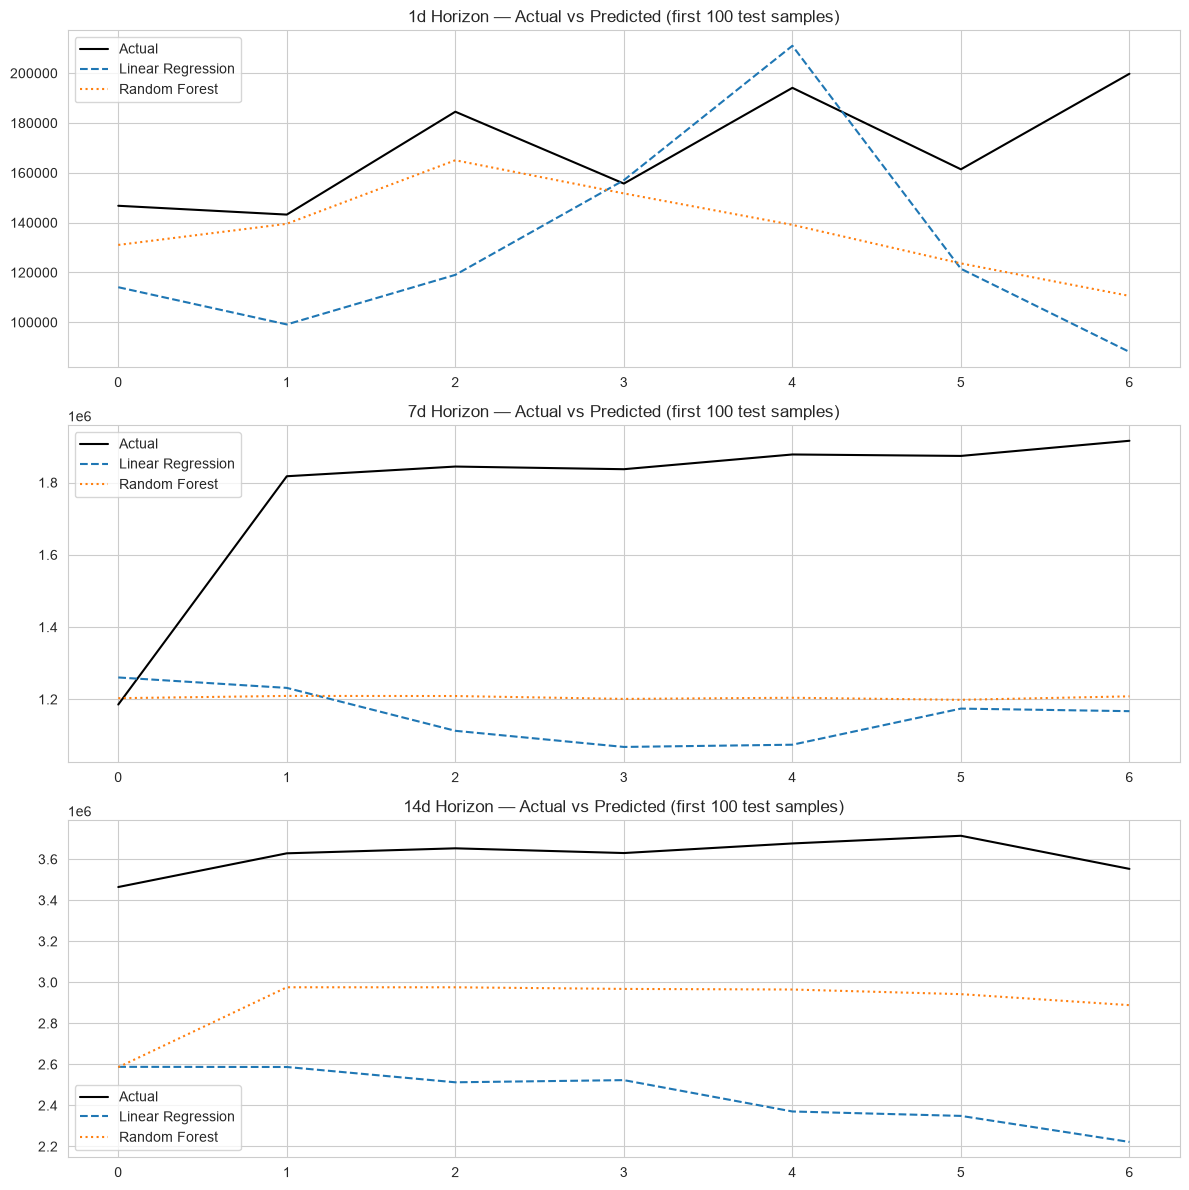

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, horizon in zip(axes, ["1d", "7d", "14d"]):
    y_te = y_test_by_horizon[horizon].values[:100]
    ax.plot(y_te, label="Actual", color="black", linewidth=1.5)
    ax.plot(predictions[horizon]["linear_regression"][:100], label="Linear Regression", linestyle="--")
    ax.plot(predictions[horizon]["random_forest"][:100], label="Random Forest", linestyle=":")
    ax.set_title(f"{horizon} Horizon — Actual vs Predicted (first 100 test samples)")
    ax.legend()
plt.tight_layout()
plt.show()

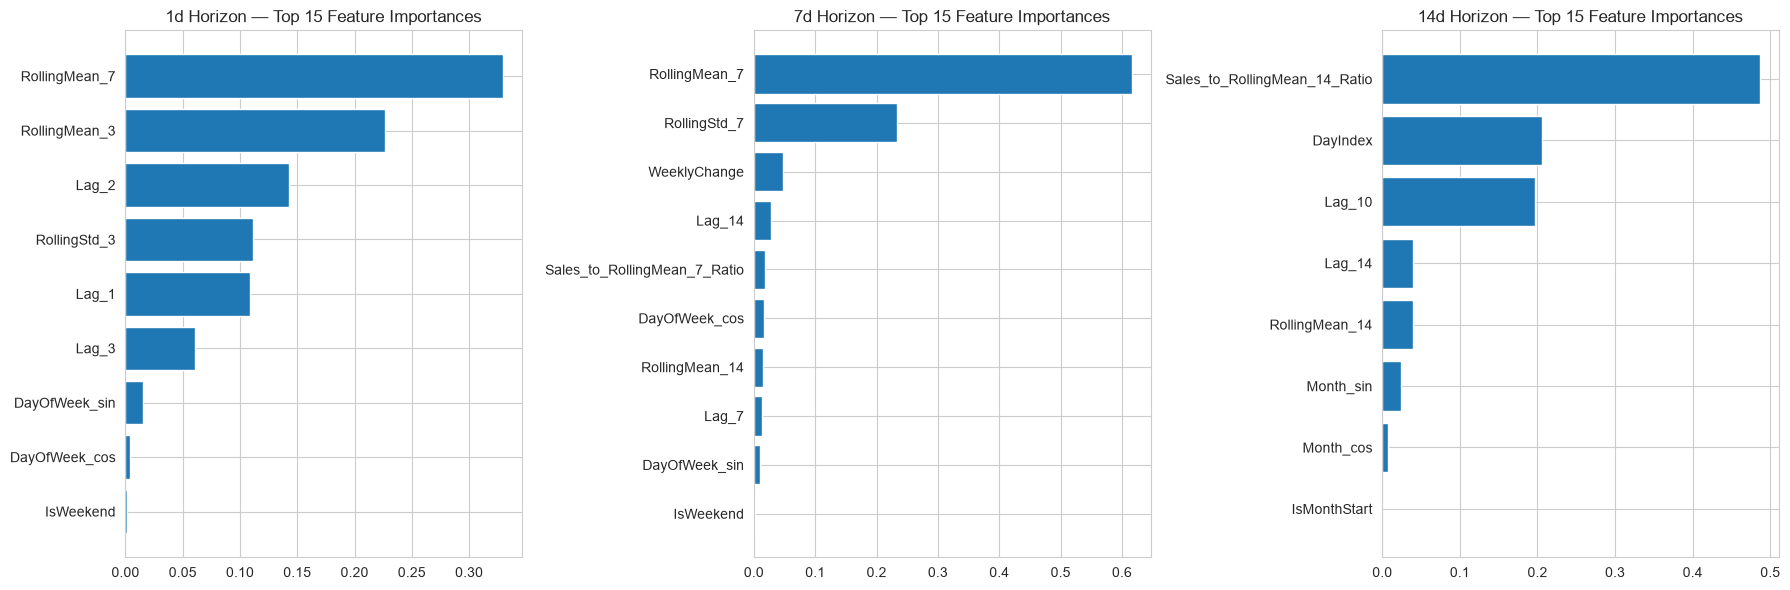

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, horizon in zip(axes, ["1d", "7d", "14d"]):
    top15 = importance_by_horizon[horizon].head(15).sort_values()
    ax.barh(top15.index, top15.values)
    ax.set_title(f"{horizon} Horizon — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

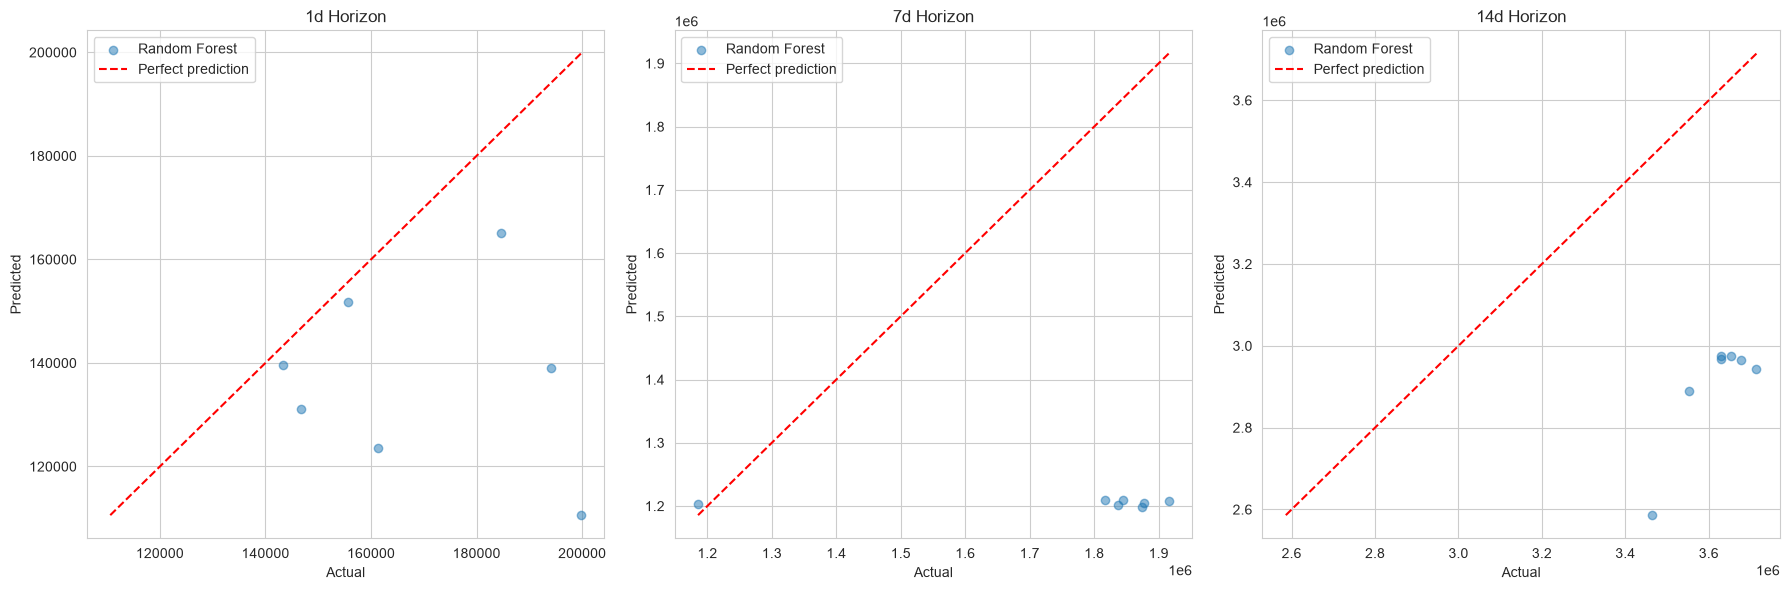

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, horizon in zip(axes, ["1d", "7d", "14d"]):
    y_te = y_test_by_horizon[horizon]
    ax.scatter(y_te, predictions[horizon]["random_forest"], alpha=0.5, label="Random Forest")
    lims = [min(y_te.min(), predictions[horizon]["random_forest"].min()),
            max(y_te.max(), predictions[horizon]["random_forest"].max())]
    ax.plot(lims, lims, "r--", label="Perfect prediction")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{horizon} Horizon")
    ax.legend()
plt.tight_layout()
plt.show()

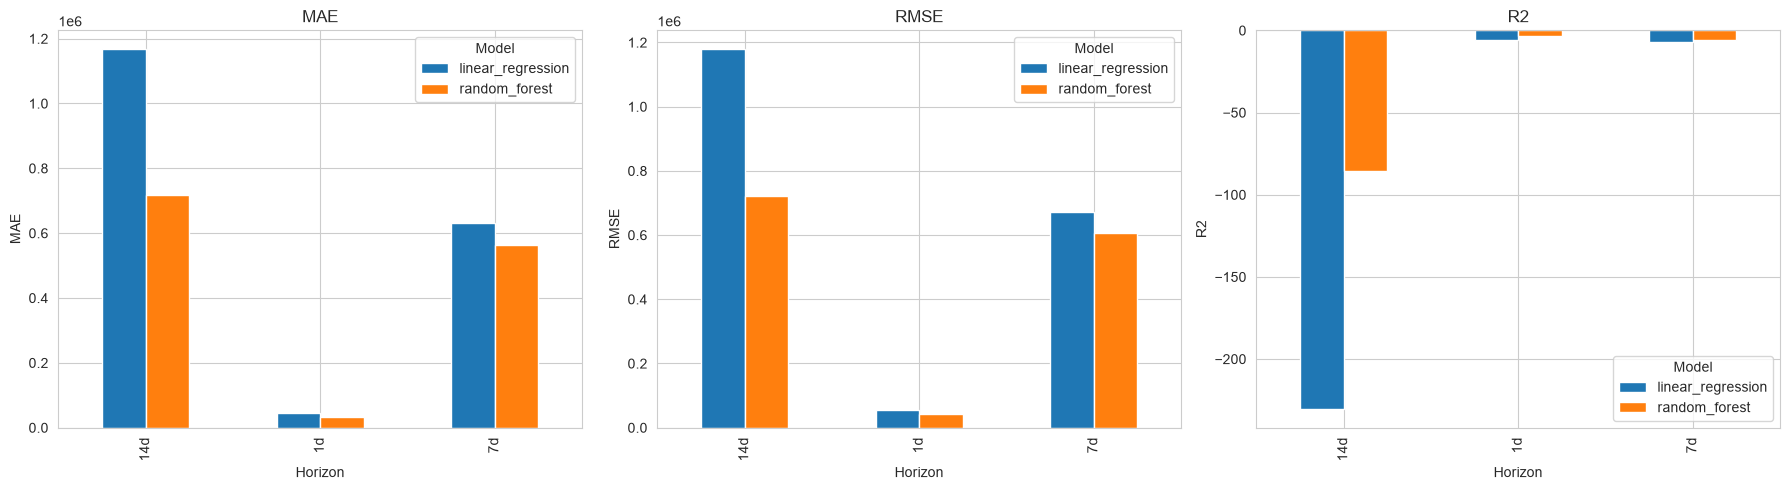

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    pivot = metrics_df.pivot(index="Horizon", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
plt.tight_layout()
plt.show()

### 8.5 Interpretation and Recommendations
- Model selection per horizon
- Horizon comparison
- Key consistently-important features
- Business insights and documented limitations

In [45]:
best_per_horizon = metrics_df.loc[metrics_df.groupby("Horizon")["MAE"].idxmin()]
print("Best model per horizon (lowest MAE):")
print(best_per_horizon[["Horizon", "Model", "MAE", "RMSE", "R2"]])

best_horizon = metrics_df.loc[metrics_df["R2"].idxmax()]
print(f"\nBest overall horizon/model combination: {best_horizon['Horizon']} — {best_horizon['Model']} (R2={best_horizon['R2']:.3f})")

print(f"\nFeatures consistently important across all horizons: {consistently_important}")

print("""
Limitations to document manually:
- Model only uses historical sales patterns — no external factors (weather, holidays, local events, promotions)
- Performance depends heavily on how much history is available
- Random Forest captures non-linear patterns but can overfit on a small dataset
- Longer horizons (14-day) are inherently harder to predict accurately than short ones
- The 14-day horizon replaces the originally-specified 30-day horizon, due to only 60 days of raw data being available
""")

Best model per horizon (lowest MAE):
  Horizon          Model            MAE           RMSE         R2
5     14d  random_forest  717037.012394  721062.004390 -85.580492
1      1d  random_forest   32112.375099   43191.535114  -3.067951
3      7d  random_forest  564630.134128  607954.373732  -5.514590

Best overall horizon/model combination: 1d — random_forest (R2=-3.068)

Features consistently important across all horizons: set()

Limitations to document manually:
- Model only uses historical sales patterns — no external factors (weather, holidays, local events, promotions)
- Performance depends heavily on how much history is available
- Random Forest captures non-linear patterns but can overfit on a small dataset
- Longer horizons (14-day) are inherently harder to predict accurately than short ones
- The 14-day horizon replaces the originally-specified 30-day horizon, due to only 60 days of raw data being available

